# Mini-Project 3: Lake Victoria Fish Stock & Export Risk Model

**Questions from the Jinja fish-export cooperative:** (a) is our harvesting rate sustainable, and (b) how risky is our revenue?

**Code layout:** the classes live in `src/fishery.py`: `FishStock`, `PriceModel`, `RiskAssessor` and `FisheryScenario` (composition).

**Units:** stock and harvest are in tonnes, time is in weeks and price is in UGX/kg. Revenue = harvest (t) × 1,000 kg/t × price.

In [1]:
import sys
from pathlib import Path
ROOT = Path.cwd() if (Path.cwd() / "src").exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.common.nbsetup import setup_plotting, FIG_DIR
from src.population import fibonacci
from src.fishery import (FishStock, PriceModel, RiskAssessor, FisheryScenario,
                         closed_season_mask, KG_PER_TONNE)

setup_plotting()
SEED = 7
pd.set_option("display.float_format", "{:,.2f}".format)
bn = lambda x: x / 1e9          # helper: UGX -> billions of UGX

## Task 1: Baseline, the Fibonacci "stock"

In [2]:
fib_stock = fibonacci(15)
print(fib_stock)
print("Ratio of the last two values:", fib_stock[-1] / fib_stock[-2])

[1, 1, 2, 3, 5, 8, 13, 21, 34, 55, 89, 144, 233, 377, 610]
Ratio of the last two values: 1.6180371352785146


**Why unbounded Fibonacci growth is biologically unrealistic.** Fibonacci numbers grow geometrically by a factor of about 1.618 per step, forever. That assumes every fish survives and reproduces and that food, space and oxygen never run out. Lake Victoria has a finite **carrying capacity**. As density rises, competition, predation (for example by Nile perch), disease and low oxygen all slow growth, so a real population levels off rather than exploding. The Fibonacci sequence also has **no harvest term and no parameters** to fit to survey data, so it can't answer whether a catch rate is sustainable. The logistic model below fixes both problems: growth is fastest at intermediate stock levels, it stops at $K$, and harvesting appears explicitly.

## Task 2: `FishStock` with logistic growth and harvesting
$N_{t+1} = N_t + rN_t\left(1 - \frac{N_t}{K}\right) - hN_t$, with $r = 0.4$, $K = 10{,}000$ t, $N_0 = 4{,}000$ t, simulated over 52 weeks.

**Theory used as a check.** Setting $N_{t+1} = N_t$ gives the equilibrium $N^* = K(1 - h/r)$ and the sustained catch $Y = hN^* = hK(1-h/r)$. The catch is largest at $h = r/2 = 0.2$, where $Y = rK/4$ = **MSY = 1,000 t/week**.

In [3]:
base = FishStock(r=0.4, K=10_000, N0=4_000, h=0.10)
print(base)
res = base.simulate(52)
print(f"Week 1 by hand: 4000 + 0.4*4000*(1-0.4) - 0.1*4000 = {4000 + 0.4*4000*0.6 - 400:.0f};  model: {res.stock[1]:.0f}")
assert np.isclose(res.stock[1], 4000 + 0.4 * 4000 * 0.6 - 400)
print(f"Final stock after 52 weeks: {res.final_stock:,.1f} t (theory N* = {base.equilibrium_stock:,.0f} t)")
print(f"MSY = rK/4 = {base.msy:,.0f} t/week")

FishStock(r=0.4, K=10,000, N0=4,000, h=0.1)
Week 1 by hand: 4000 + 0.4*4000*(1-0.4) - 0.1*4000 = 4560;  model: 4560
Final stock after 52 weeks: 7,500.0 t (theory N* = 7,500 t)
MSY = rK/4 = 1,000 t/week


## Task 3: `PriceModel` as a bounded random walk
$P_{t+1} = \operatorname{clip}(P_t + \varepsilon_t,\ 9{,}000,\ 16{,}000)$ with $\varepsilon_t\sim N(0, 400)$ UGX/kg. Week 0 starts at UGX 12,000/kg. I chose σ = 400 (about 3% a week) as a plausible volatility for export fish prices. It is an assumption, not an estimate.

In [4]:
prices = PriceModel(start=12_000, lower=9_000, upper=16_000, sigma=400, seed=SEED)
scenario = FisheryScenario(base, prices, weeks=52)
out = scenario.run()
weekly = pd.DataFrame({"stock_t": out["sim"].stock[:-1], "harvest_t": out["sim"].harvest,
                       "price_ugx_kg": out["price"], "revenue_bn_ugx": bn(out["revenue"])},
                      index=pd.RangeIndex(1, 53, name="week"))
weekly.head()

,stock_t,harvest_t,price_ugx_kg,revenue_bn_ugx
week,,,,
1,"4,000.00",400.00,"12,000.00",4.80
2,"4,560.00",456.00,"12,119.50",5.53
3,"5,096.26",509.63,"12,009.84",6.12
4,"5,586.26",558.63,"11,653.61",6.51
5,"6,013.89",601.39,"11,471.74",6.90


## Task 4: Revenue statistics, and why a variance threshold of 50,000 is meaningless

In [5]:
ra = RiskAssessor()
desc = ra.describe(out["revenue"])
pd.Series({"mean (UGX)": desc["mean"], "median (UGX)": desc["median"],
           "variance (UGX²)": desc["variance"], "std dev (UGX)": desc["stdev"],
           "CV (unitless)": desc["cv"]}).apply(lambda v: f"{v:,.4g}")

mean (UGX)         7.128e+09
median (UGX)       6.903e+09
variance (UGX²)    5.322e+17
std dev (UGX)      7.295e+08
CV (unitless)         0.1023
dtype: str

In [6]:
UGX_PER_USD = 3_700   # illustrative exchange rate
rev_usd = out["revenue"] / UGX_PER_USD
d_usd = ra.describe(rev_usd)
print(f"Variance in UGX² : {desc['variance']:.3e}  -> '> 50,000'? {desc['variance'] > 50_000}")
print(f"Variance in USD² : {d_usd['variance']:.3e}  (divided by 3,700² = {UGX_PER_USD**2:,})")
print(f"Variance in UGX², revenue in millions: {ra.describe(out['revenue']/1e6)['variance']:.3e}")
print(f"CV in UGX = {desc['cv']:.4f};  CV in USD = {d_usd['cv']:.4f}  <- identical")

Variance in UGX² : 5.322e+17  -> '> 50,000'? True
Variance in USD² : 3.887e+10  (divided by 3,700² = 13,690,000)
Variance in UGX², revenue in millions: 5.322e+05
CV in UGX = 0.1023;  CV in USD = 0.1023  <- identical


**Why the old rule is meaningless.** Variance is measured in **squared currency units** (UGX²). Weekly revenue here is several billion UGX, so its variance is around $10^{17}$ UGX². It will always exceed 50,000, whether the business is stable or chaotic. The rule also depends on the unit chosen. The same revenue expressed in USD, or in millions of UGX, gives a completely different variance, and could fall below 50,000 with no change in the actual risk. A threshold has to be **scale-free** to mean anything. The coefficient of variation, CV = σ/μ, has no units: it stays the same in any currency and measures volatility *relative to the size of the business*.

## Task 5: `RiskAssessor` and Monte Carlo Value-at-Risk
**Risk rule, based on the CV of weekly revenue:**

| CV | Class | Reasoning |
|---|---|---|
| < 0.10 | Low | A typical week is within ±10% of normal. Ordinary working capital absorbs it. |
| 0.10–0.25 | Moderate | Swings of 10–25% are large enough to disrupt payments to fishers and processors, so a cash buffer is needed. |
| ≥ 0.25 | High | A typical week misses the average by a quarter or more, and the price band (9,000–16,000, about ±30% of 12,000) is being fully used. Hedging or forward contracts are needed. |

**VaR:** I simulate 1,000 price paths and total the annual revenue on each. The 5% quantile $q_{0.05}$ is the level revenue falls below in only 1 year in 20. I report **VaR₉₅ = mean − $q_{0.05}$**, the shortfall against the expected revenue at 95% confidence.

In [7]:
mc_scenario = FisheryScenario(base, PriceModel(sigma=400, seed=SEED), weeks=52)
annual = mc_scenario.monte_carlo_annual_revenue(n_paths=1000)
var = ra.value_at_risk(annual, alpha=0.05)
print(f"Expected annual revenue : UGX {bn(var['mean']):,.1f} bn")
print(f"5% quantile             : UGX {bn(var['quantile']):,.1f} bn")
print(f"95% VaR (shortfall)     : UGX {bn(var['VaR']):,.1f} bn  ({var['VaR']/var['mean']:.1%} of expected)")
print("Weekly-revenue risk class (h = 0.10):", ra.classify(out["revenue"]))

Expected annual revenue : UGX 448.3 bn
5% quantile             : UGX 373.0 bn
95% VaR (shortfall)     : UGX 75.3 bn  (16.8% of expected)
Weekly-revenue risk class (h = 0.10): Moderate


## Task 6: Scenario analysis, h = 0.05, 0.10, 0.20, 0.30
For a fair comparison, every harvest rate uses the **same** price path and the **same** 1,000 Monte Carlo paths (common random numbers). The differences then come only from the harvest rate.

In [8]:
H_RATES = [0.05, 0.10, 0.20, 0.30]
common_path = PriceModel(sigma=400, seed=SEED).simulate(52)
mc_paths = PriceModel(sigma=400, seed=SEED + 1).simulate_paths(52, 1000)
rows, trajectories, annual_by_h = [], {}, {}
for h in H_RATES:
    fs = FishStock(h=h)
    run = FisheryScenario(fs, PriceModel(), weeks=52).run(price_path=common_path)
    sim = run["sim"]
    trajectories[h] = sim.stock
    annual_by_h[h] = (mc_paths * sim.harvest * KG_PER_TONNE).sum(axis=1)
    d = ra.describe(run["revenue"])
    v = ra.value_at_risk(annual_by_h[h])
    rows.append({"h": h, "final stock (t)": sim.final_stock, "theory N* (t)": fs.equilibrium_stock,
                 "avg catch (t/wk)": sim.harvest.mean(), "equilibrium yield (t/wk)": fs.equilibrium_yield,
                 "% of MSY": fs.equilibrium_yield / fs.msy * 100,
                 "total revenue (bn UGX)": bn(run["revenue"].sum()), "weekly CV": d["cv"],
                 "risk class": ra.classify_cv(d["cv"]), "95% VaR (bn UGX)": bn(v["VaR"])})
scen = pd.DataFrame(rows).set_index("h")
scen

,final stock (t),theory N* (t),avg catch (t/wk),equilibrium yield (t/wk),% of MSY,total revenue (bn UGX),weekly CV,risk class,95% VaR (bn UGX)
h,,,,,,,,,
0.05,"8,750.00","8,750.00",417.59,437.50,43.75,215.24,0.12,Moderate,46.77
0.10,"7,500.00","7,500.00",718.51,750.00,75.00,370.66,0.10,Moderate,80.21
0.20,"4,999.99","5,000.00",978.30,"1,000.00",100.00,506.73,0.08,Low,107.46
0.30,"2,503.72","2,500.00",816.56,750.00,75.00,429.13,0.24,Moderate,83.99


**Comparison with MSY (1,000 t/week).**
* **h = 0.20 = r/2 is the MSY harvest rate.** The stock settles at $K/2$ = 5,000 t and the catch at about 1,000 t/week. It gives the **highest revenue** of the four options.
* **h = 0.05 and 0.10** are *under*-fishing. The stock stays high (8,750 and 7,500 t), which is safe, but the cooperative gives up 56% and 25% of the potential catch.
* **h = 0.30** is *over*-fishing. It is still sustainable in the narrow sense, because the stock does not collapse, but the stock is pushed down to 2,500 t and the catch **falls** to 750 t/week. It earns less than h = 0.20 while leaving the stock much more exposed to shocks such as a bad breeding year or pollution. Any $h \ge r = 0.4$ drives the stock to zero.
* The weekly CV is lowest at h = 0.20 because the stock starts at 4,000 t, already close to its equilibrium of 5,000 t, so revenue moves mainly with price. At the other rates the stock is still adjusting during the year, which adds a trend to revenue and pushes the CV into the Moderate class.

## Task 7: Stock trajectories and the annual-revenue histogram

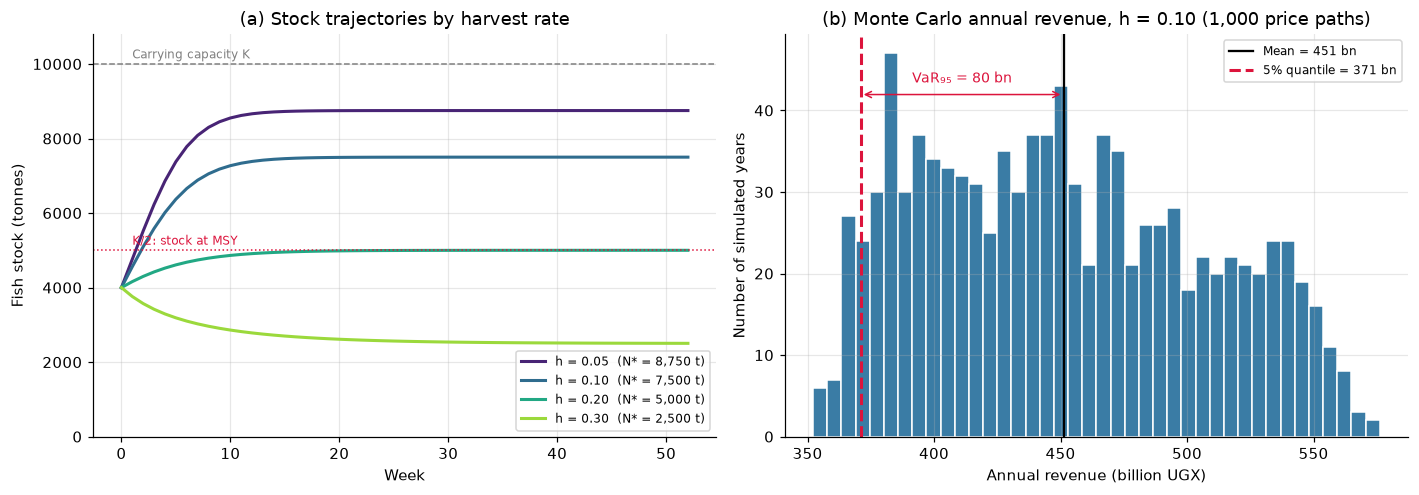

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
ax = axes[0]
colors = plt.cm.viridis(np.linspace(0.1, 0.85, len(H_RATES)))
for (h, traj), c in zip(trajectories.items(), colors):
    ax.plot(np.arange(53), traj, color=c, lw=2, label=f"h = {h:.2f}  (N* = {FishStock(h=h).equilibrium_stock:,.0f} t)")
ax.axhline(10_000, color="grey", ls="--", lw=1)
ax.text(1, 10_150, "Carrying capacity K", color="grey", fontsize=8)
ax.axhline(5_000, color="crimson", ls=":", lw=1)
ax.text(1, 5_150, "K/2: stock at MSY", color="crimson", fontsize=8)
ax.set(xlabel="Week", ylabel="Fish stock (tonnes)", title="(a) Stock trajectories by harvest rate", ylim=(0, 10_800))
ax.legend(fontsize=8, loc="lower right")

ax = axes[1]
a = bn(annual_by_h[0.10])
v = ra.value_at_risk(annual_by_h[0.10])
ax.hist(a, bins=40, color="#3a7ca5", edgecolor="white")
ax.axvline(bn(v["mean"]), color="black", lw=1.5, label=f"Mean = {bn(v['mean']):,.0f} bn")
ax.axvline(bn(v["quantile"]), color="crimson", lw=2, ls="--", label=f"5% quantile = {bn(v['quantile']):,.0f} bn")
ax.annotate("", xy=(bn(v["quantile"]), ax.get_ylim()[1] * 0.85), xytext=(bn(v["mean"]), ax.get_ylim()[1] * 0.85),
            arrowprops=dict(arrowstyle="<->", color="crimson"))
ax.text((bn(v["quantile"]) + bn(v["mean"])) / 2, ax.get_ylim()[1] * 0.88, f"VaR₉₅ = {bn(v['VaR']):,.0f} bn",
        ha="center", color="crimson", fontsize=9)
ax.set(xlabel="Annual revenue (billion UGX)", ylabel="Number of simulated years",
       title="(b) Monte Carlo annual revenue, h = 0.10 (1,000 price paths)")
ax.legend(fontsize=8, loc="upper right")
fig.tight_layout()
fig.savefig(FIG_DIR / "p3_stock_and_var.png", bbox_inches="tight")
plt.show()

## Extension: an 8-week closed season each year over 5 years
The season is closed for weeks 14–21 each year, roughly April–May, when many Lake Victoria species spawn after the long rains. During those weeks $h = 0$. Revenue uses 1,000 five-year price paths.

In [10]:
YEARS, W = 5, 260
open_mask = closed_season_mask(YEARS, closed_weeks=8, start_week=13)
long_paths = PriceModel(sigma=400, seed=SEED + 2).simulate_paths(W, 1000)
rows, long_traj = [], {}
for h in [0.10, 0.20, 0.30, 0.35]:
    for label, mask in [("open all year", None), ("8-wk closed season", open_mask)]:
        sim = FishStock(h=h).simulate(W, mask)
        rev = (long_paths * sim.harvest * KG_PER_TONNE).sum(axis=1)
        long_traj[(h, label)] = sim.stock
        rows.append({"h": h, "policy": label, "5-yr catch (t)": sim.total_harvest,
                     "final stock (t)": sim.final_stock, "min stock (t)": sim.stock.min(),
                     "mean 5-yr revenue (bn)": bn(rev.mean()), "5% quantile (bn)": bn(np.percentile(rev, 5))})
cs = pd.DataFrame(rows).set_index(["h", "policy"])
cs["Δ revenue vs open"] = cs["mean 5-yr revenue (bn)"].groupby(level="h").transform(lambda s: (s / s.iloc[0] - 1) * 100).map("{:+.1f}%".format)
cs

5-yr catch (t)  final stock (t)  min stock (t)  \
h    policy                                                               
0.10 open all year           193,362.51         7,500.00       4,000.00   
     8-wk closed season      166,799.32         7,500.03       4,000.00   
0.20 open all year           258,871.70         5,000.00       4,000.00   
     8-wk closed season      234,760.95         5,002.02       4,000.00   
0.30 open all year           198,472.16         2,500.00       2,500.00   
     8-wk closed season      212,686.37         2,560.74       2,515.13   
0.35 open all year           123,682.77         1,250.00       1,250.00   
     8-wk closed season      174,572.12         1,480.84       1,358.19   

                         mean 5-yr revenue (bn)  5% quantile (bn)  \
h    policy                                                         
0.10 open all year                     2,399.93          2,011.82   
     8-wk closed season                2,071.27          1,736.31   
0.20 open all year                     3,212.54          2,695.04   
     8-wk closed season                2,914.53          2,444.91   
0.30 open all year                     2,461.21          2,072.09   
     8-wk closed season                2,638.73          2,220.30   
0.35 open all year                     1,530.88          1,296.95   
     8-wk closed season                2,164.20          1,823.76   

                        Δ revenue vs open  
h    policy                                
0.10 open all year                  +0.0%  
     8-wk closed season            -13.7%  
0.20 open all year                  +0.0%  
     8-wk closed season             -9.3%  
0.30 open all year                  +0.0%  
     8-wk closed season             +7.2%  
0.35 open all year                  +0.0%  
     8-wk closed season            +41.4%

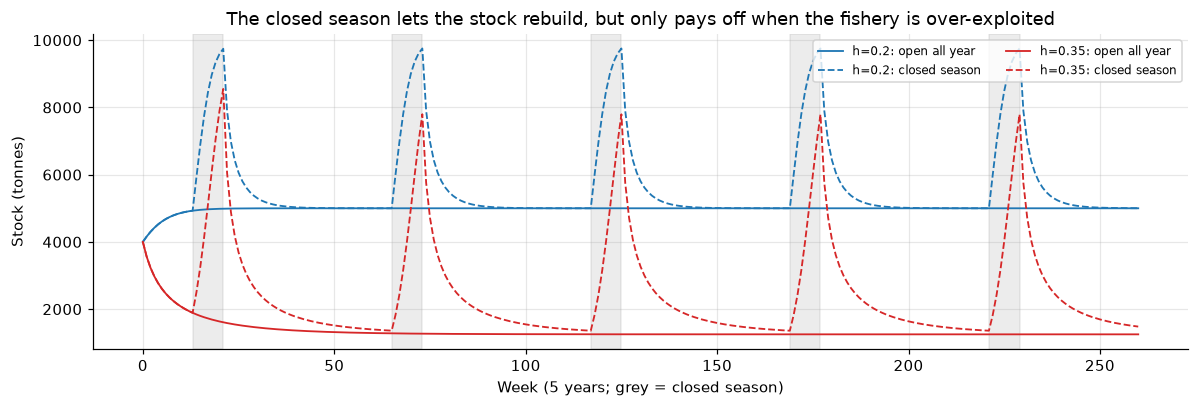

In [11]:
fig, ax = plt.subplots(figsize=(11, 3.8))
for h, c in zip([0.20, 0.35], ["tab:blue", "tab:red"]):
    ax.plot(long_traj[(h, "open all year")], color=c, lw=1.2, label=f"h={h}: open all year")
    ax.plot(long_traj[(h, "8-wk closed season")], color=c, lw=1.2, ls="--", label=f"h={h}: closed season")
for y in range(YEARS):
    ax.axvspan(y * 52 + 13, y * 52 + 21, color="grey", alpha=0.15)
ax.set(xlabel="Week (5 years; grey = closed season)", ylabel="Stock (tonnes)",
       title="The closed season lets the stock rebuild, but only pays off when the fishery is over-exploited")
ax.legend(fontsize=8, ncol=2)
fig.tight_layout()
plt.show()

**Effect of the closed season.** The result depends on the harvest rate:
* At **h ≤ 0.20** the stock is already at or above the MSY level. Closing for 8 weeks simply gives up about 15% of the fishing weeks, and 5-year revenue **falls** by about 9–14%.
* At **h = 0.30 and 0.35** the stock is being over-fished. During the closure it recovers towards the fast-growth zone near $K/2$, and after reopening the higher stock yields more per week. 5-year revenue **rises** by about 7% at h = 0.30 and about 40% at h = 0.35.

A closed season is therefore a useful tool **for an over-exploited fishery**, and it also protects spawning fish, which this simple model doesn't capture. For a fishery already at MSY it costs revenue. Keeping the rate at about h = 0.2 gives the same protection more cheaply.

## Findings & Limitations

**Findings.** (a) *Sustainability.* The logistic model gives a clear answer that the old Fibonacci model could not. Every rate below $r = 0.4$ is sustainable, but only **h ≈ 0.20** reaches the maximum sustainable yield of about 1,000 t/week, with the stock held at $K/2$ = 5,000 t. The current base rate of h = 0.10 is **safe but under-uses the resource**: it lands about 25% less fish than MSY. Going above h = 0.2 is the worst of both worlds: less fish and a thinner safety margin. (b) *Revenue risk.* The variance-greater-than-50,000 rule is meaningless because variance is in UGX², so I use the CV instead. Weekly revenue risk is *Moderate* (CV about 0.10–0.24), except at h = 0.20, where it is *Low* (CV about 0.08). Across 1,000 simulated years, annual revenue at h = 0.10 falls about UGX 75–80 bn (about 17%) below its expected level in 1 year in 20. That is the reserve or hedge the cooperative should plan for. Price, not biology, drives the year-to-year risk, so forward sales contracts would reduce risk more than changing the catch would.

**Limitations.** (1) The parameters are illustrative. An $r$ of 0.4 *per week* is extremely fast, and 1,000 t/week would be a very large share of Uganda's Lake Victoria catch. Real work would estimate $r$ and $K$ from NaFIRRI or LVFO stock surveys. (2) The model is deterministic apart from price. Real stocks face recruitment shocks, disease, illegal fishing and water hyacinth. (3) It models a single species with no age structure. (4) Price and harvest are independent in the model, whereas in reality a large catch pushes prices down. (5) The random-walk parameters (σ = 400, hard price bounds) are assumptions, and clipping piles probability up at the bounds.